In [1]:
import json
from pathlib import Path
import torch
import numpy as np

from monai.data import Dataset, DataLoader, decollate_batch
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, ConfusionMatrixMetric
from monai.networks.nets import SegResNetDS

from monai.transforms import (
    Activations,
    AsDiscrete,
    Compose,
    CropForegroundd,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    Orientationd,
    ScaleIntensityRanged,
    Spacingd,
    ToTensord,
)


ModuleNotFoundError: No module named 'torch'

In [ ]:

# ==========================================
# 1. Rutas (Formato WSL/Linux)
# ==========================================
dataset_dir = Path("/mnt/d/Semestre 11/Desarrollo Proyecto de Título/Proyecto/PulmoSeg-3D/local_storage/models/datasets/Task06_Lung")
model_path = Path("/mnt/d/Semestre 11/Desarrollo Proyecto de Título/Proyecto/PulmoSeg-3D/local_storage/models/tumor_segresnet_v1/trained_tumor_segresnet_v1_model.pt")




In [ ]:

# ==========================================
# 2. Reconstruir el set de Validación
# ==========================================
with open(dataset_dir / "dataset.json", "r") as f:
    meta = json.load(f)

data_list = []
for entry in meta["training"]:
    img_path = dataset_dir / entry["image"].lstrip("./")
    lbl_path = dataset_dir / entry["label"].lstrip("./")
    if img_path.exists() and lbl_path.exists():
        data_list.append({"image": str(img_path), "label": str(lbl_path)})

# Tomar el primer 20% tal como se hizo en train_tumor_segresnet.py
val_split = 0.2
n_val = max(1, int(len(data_list) * val_split))
val_files = data_list[:n_val]
print(f"Total casos de validación a evaluar: {len(val_files)}")


In [ ]:

# ==========================================
# 3. Transformaciones (Valores exactos de Auto3DSeg)
# ==========================================
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    # Usamos la 'resample_resolution' exacta que calculó Auto3DSeg
    Spacingd(keys=["image", "label"], pixdim=(0.78515625, 0.78515625, 0.99787235), mode=("bilinear", "nearest")),
    # Usamos los 'intensity_bounds' exactos que calculó Auto3DSeg
    ScaleIntensityRanged(keys=["image"], a_min=-909.545, a_max=223.792, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image", allow_smaller=True),
    ToTensord(keys=["image", "label"]),
])

val_ds = Dataset(data=val_files, transform=val_transforms)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=0)



In [ ]:

# ==========================================
# 4. Cargar Modelo SegResNetDS (Auto3DSeg)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model = SegResNetDS(
    init_filters=32,
    blocks_down=[1, 2, 2, 4, 4],
    blocks_up=[1, 1, 1, 1],
    in_channels=1,
    out_channels=2,
    norm="INSTANCE", # Arregla el error de las capas de normalización
    dsdepth=4,       # Arregla el error de las capas extra (heads)
).to(device)



# Cargar el archivo .pt
checkpoint = torch.load(model_path, map_location=device)

if "state_dict" in checkpoint:
    model.load_state_dict(checkpoint["state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()




In [ ]:

# ==========================================
# 5. Configurar Métricas
# ==========================================
dice_metric = DiceMetric(include_background=False, reduction="mean")

# Pedimos a la matriz de confusión que nos calcule estas métricas (ignorando el fondo)
conf_matrix_metric = ConfusionMatrixMetric(
    include_background=False, 
    metric_name=["accuracy", "precision", "sensitivity", "specificity"]
)

post_pred = Compose([Activations(softmax=True), AsDiscrete(argmax=True, to_onehot=2)])
post_label = AsDiscrete(to_onehot=2)




In [ ]:

# ==========================================
# 6. Ejecutar Inferencia
# ==========================================
print("Iniciando evaluación... esto puede tardar un poco dependiendo de tu GPU/CPU.")
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        print(f"Procesando caso {i+1} de {len(val_files)}...")
        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)

        # Inferencia con ventana deslizante (mismos parches de 96x96x96 del entrenamiento)
        val_outputs = sliding_window_inference(
            inputs=val_inputs, roi_size=(96, 96, 96), sw_batch_size=4, predictor=model
        )

        val_outputs_list = decollate_batch(val_outputs)
        val_labels_list = decollate_batch(val_labels)

        val_preds = [post_pred(p) for p in val_outputs_list]
        val_lbls = [post_label(l) for l in val_labels_list]

        # Alimentar las métricas
        dice_metric(y_pred=val_preds, y=val_lbls)
        conf_matrix_metric(y_pred=val_preds, y=val_lbls)


In [ ]:

# ==========================================
# 7. Resultados Finales
# ==========================================
mean_dice = dice_metric.aggregate().item()
cm_metrics = conf_matrix_metric.aggregate()

# Extraer las métricas de la tupla (el orden corresponde al definido en metric_name)
accuracy = cm_metrics[0].item()
precision = cm_metrics[1].item()
sensitivity = cm_metrics[2].item() # También conocido como Recall
specificity = cm_metrics[3].item()

print("\n" + "="*40)
print(" RESULTADOS DE VALIDACIÓN (Vóxel a Vóxel)")
print("="*40)
print(f" Dice Score (Overlap) : {mean_dice:.4f} ({mean_dice*100:.2f}%)")
print(f" Accuracy             : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" Precisión            : {precision:.4f} ({precision*100:.2f}%)")
print(f" Sensibilidad (Recall): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f" Especificidad        : {specificity:.4f} ({specificity*100:.2f}%)")
print("="*40)

In [ ]:
# Inspeccionar la metadata del modelo guardado
print("=== METADATA DEL MODELO ===")
print("Época en la que se guardó este archivo :", checkpoint.get("epoch", "No registrado"))
print("Mejor métrica (Dice) durante el entreno :", checkpoint.get("best_metric", "No registrado"))

# Si quieres ver qué otros datos guardó Auto3DSeg:
print("\nLlaves disponibles en el checkpoint:")
print(list(checkpoint.keys()))


In [ ]:
import pprint

# El diccionario 'config' tiene toda la receta de cómo se entrenó y preprocesó
config = checkpoint.get("config", {})

# Vamos a buscar específicamente las transformaciones que usó
if "transforms_val" in config:
    print("=== TRANSFORMACIONES DE VALIDACIÓN ORIGINALES ===")
    pprint.pprint(config["transforms_val"])
elif "transforms" in config:
    print("=== TRANSFORMACIONES ORIGINALES ===")
    pprint.pprint(config["transforms"])
else:
    print("Aquí está toda la configuración:")
    pprint.pprint(config)


## Curva de Aprendizaje y Validación (Auto3DSeg)

Visualización del progreso del entrenamiento en base al archivo `accuracy_history.csv` extraído de la instancia de GCP.

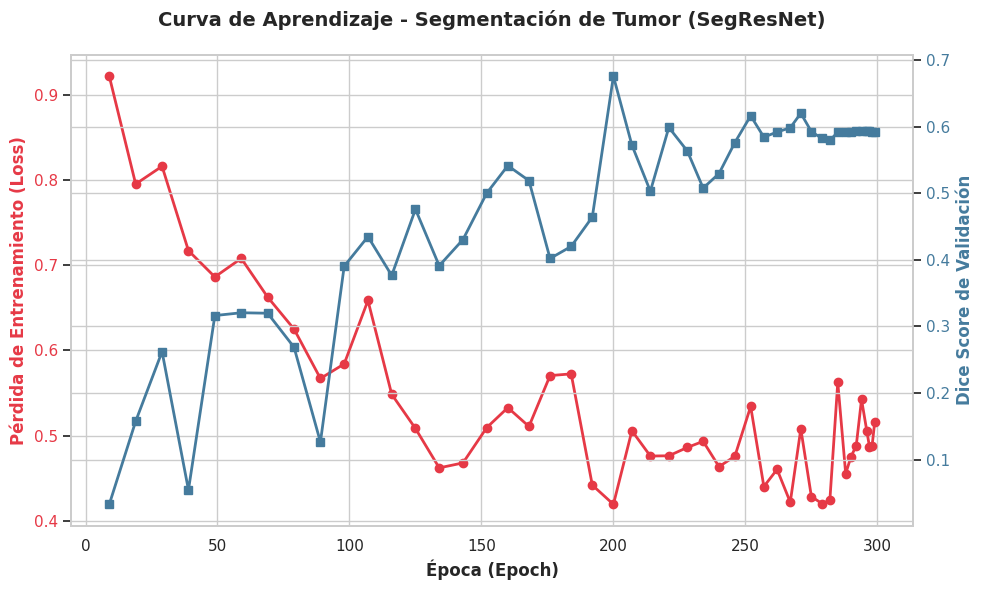

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Cargar el archivo de historial de Auto3DSeg (separado por tabulaciones)
csv_path = 'accuracy_history.csv'
df = pd.read_csv(csv_path, sep='\t', encoding='utf-16')

# Crear el gráfico
fig, ax1 = plt.subplots(figsize=(10, 6))

color_loss = '#e63946'
ax1.set_xlabel('Época (Epoch)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Pérdida de Entrenamiento (Loss)', color=color_loss, fontsize=12, fontweight='bold')
ax1.plot(df['epoch'], df['loss'], color=color_loss, marker='o', linewidth=2, label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color_loss)

# Segundo eje para la métrica (Val Dice)
ax2 = ax1.twinx()
color_metric = '#457b9d'
ax2.set_ylabel('Dice Score de Validación', color=color_metric, fontsize=12, fontweight='bold')
ax2.plot(df['epoch'], df['metric'], color=color_metric, marker='s', linewidth=2, label='Validation Dice')
ax2.tick_params(axis='y', labelcolor=color_metric)

fig.suptitle('Curva de Aprendizaje - Segmentación de Tumor (SegResNet)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


## Gráfico de Función de Pérdida

Evolución de la función de pérdida (Loss) de entrenamiento a lo largo de las épocas.

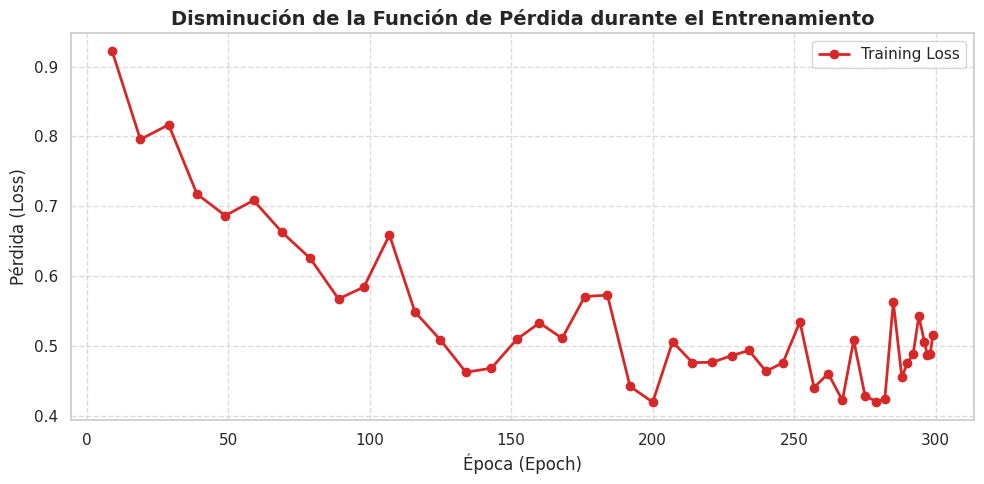

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

csv_path = 'accuracy_history.csv'
df = pd.read_csv(csv_path, sep='\t', encoding='utf-16')

plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['loss'], color='#d62828', marker='o', linewidth=2, label='Training Loss')
plt.title('Disminución de la Función de Pérdida durante el Entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Época (Epoch)', fontsize=12)
plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
